<a href="https://colab.research.google.com/github/alizasultanaesd-png/skill-morph-work/blob/main/Hourly_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hourly data analysis**

Excellent work!



For the monthly analysis: please make sure that the maps that zoom in on the study area, have a smaller range on the colorbar such that the patterns in the map are more clearly visible (In matplotlib you can change values for vmin, vmax to adjust the colorbar)



Download hourly data

https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=download

-Only 2m-temperature

-Year 2024

-Select April - May - June

-Day: all days of the month

-Time: all times of the day

-Geographical area: try the same as last time (or make it smaller if the size is too big: focusing only on the study area)



>> map of the maximum 2m-temperature

>> timeseries of 2m-temperature for 3 months in a row (it will be quite busy with 90 days in a row, 24*90 points)

>> timeseries of 2m-temperature with only the daily maximum for 3 months in a row (then you will have ~90 data points)

>> maybe another figure that you can think of..



In [11]:
from google.colab import drive
drive.mount('/content/drive')


import xarray as xr

ds = xr.open_dataset('/content/drive/MyDrive/data_stream-oper_stepType-instant.nc')
print(ds)

MessageError: Error: credential propagation was unsuccessful

In [7]:
# Variables list dekho
print(ds.variables)

NameError: name 'ds' is not defined

In [27]:
!pip install xarray netCDF4 matplotlib
!pip install cartopy

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import pandas as pd
import sys
import xarray as xr
import geopandas as gpd

**Khulna_Barisal: Hourly 2m Temperature (Apr–Jun 2024)**

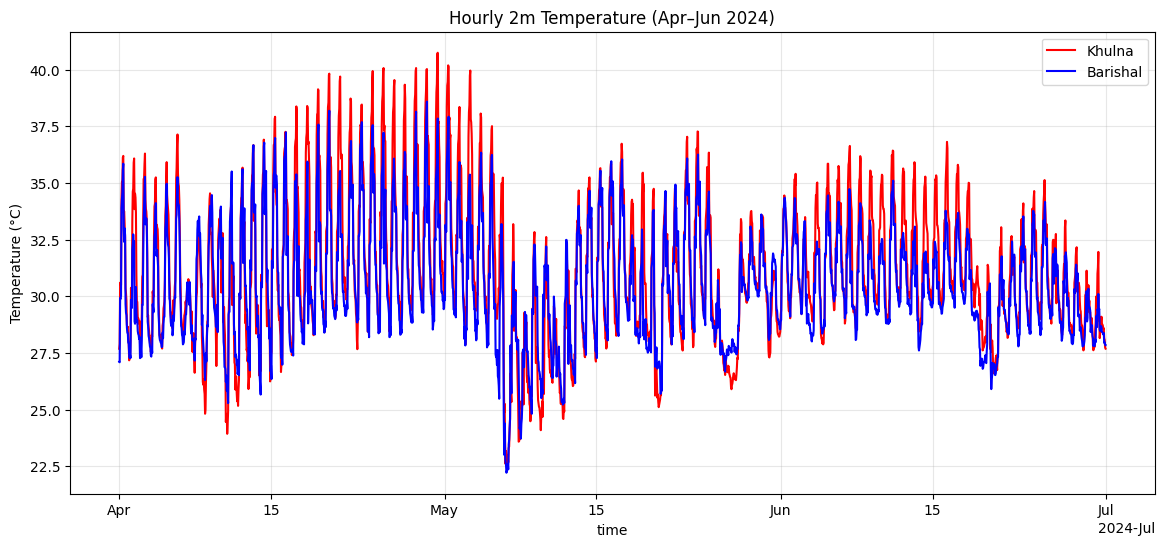

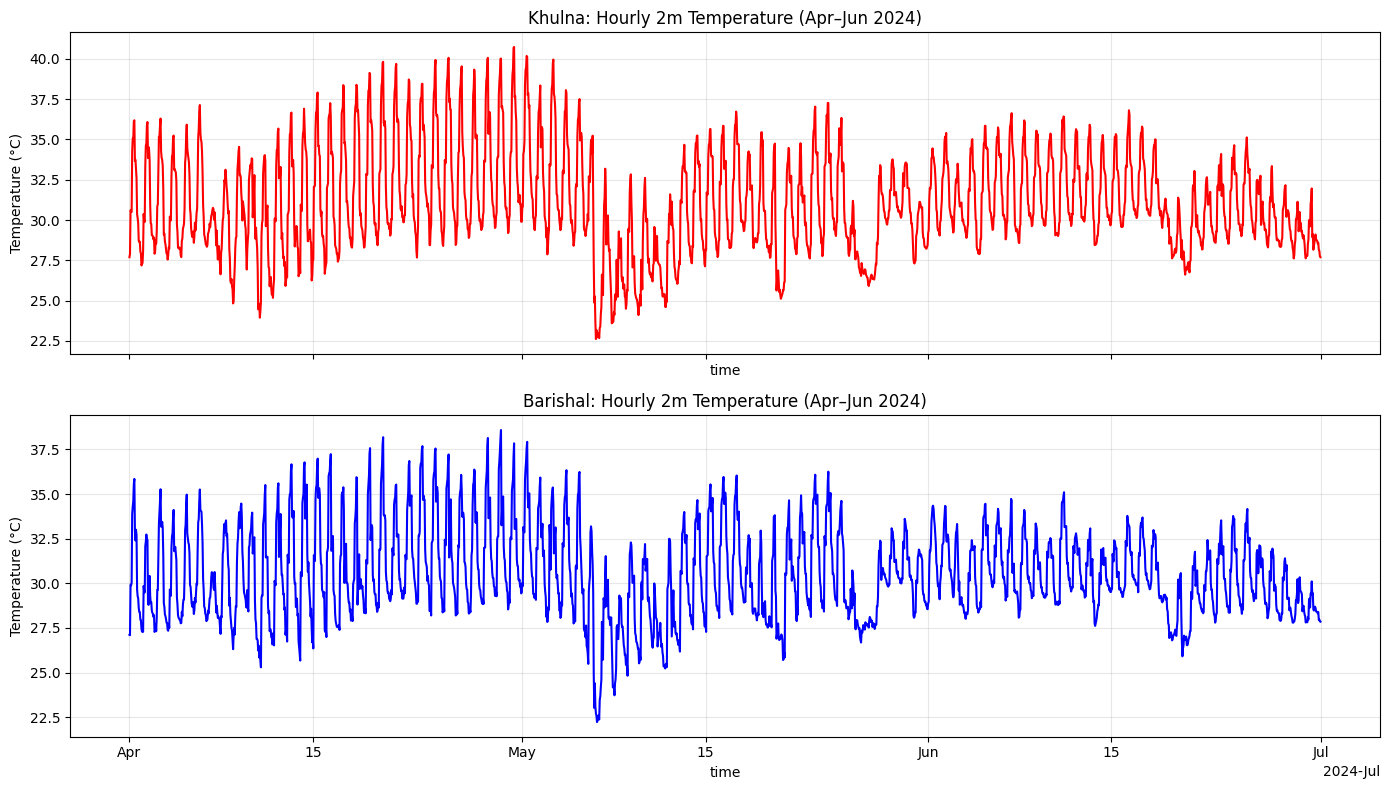

In [32]:

# --- Load your dataset ---
# Replace with your actual file path
ds = xr.open_dataset("/content/drive/MyDrive/data_stream-oper_stepType-instant.nc")

# --- Coordinates for Khulna and Barishal ---
khulna_lat, khulna_lon = 22.8, 89.6
barishal_lat, barishal_lon = 22.7, 90.4

# --- Select nearest grid points ---
khulna = ds['t2m'].sel(latitude=khulna_lat, longitude=khulna_lon, method='nearest')
barishal = ds['t2m'].sel(latitude=barishal_lat, longitude=barishal_lon, method='nearest')

# --- Subset April–June 2024 ---
subset = slice("2024-04-01", "2024-06-30")
khulna_3m = khulna.sel(valid_time=subset) - 273.15  # convert to °C
barishal_3m = barishal.sel(valid_time=subset) - 273.15

# --- Plot combined hourly time series ---
plt.figure(figsize=(14,6))
khulna_3m.plot(label="Khulna", color="red")
barishal_3m.plot(label="Barishal", color="blue")
plt.title("Hourly 2m Temperature (Apr–Jun 2024)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot separate time series ---
fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)

khulna_3m.plot(ax=axes[0], color="red")
axes[0].set_title("Khulna: Hourly 2m Temperature (Apr–Jun 2024)")
axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(True, alpha=0.3)

barishal_3m.plot(ax=axes[1], color="blue")
axes[1].set_title("Barishal: Hourly 2m Temperature (Apr–Jun 2024)")
axes[1].set_ylabel("Temperature (°C)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


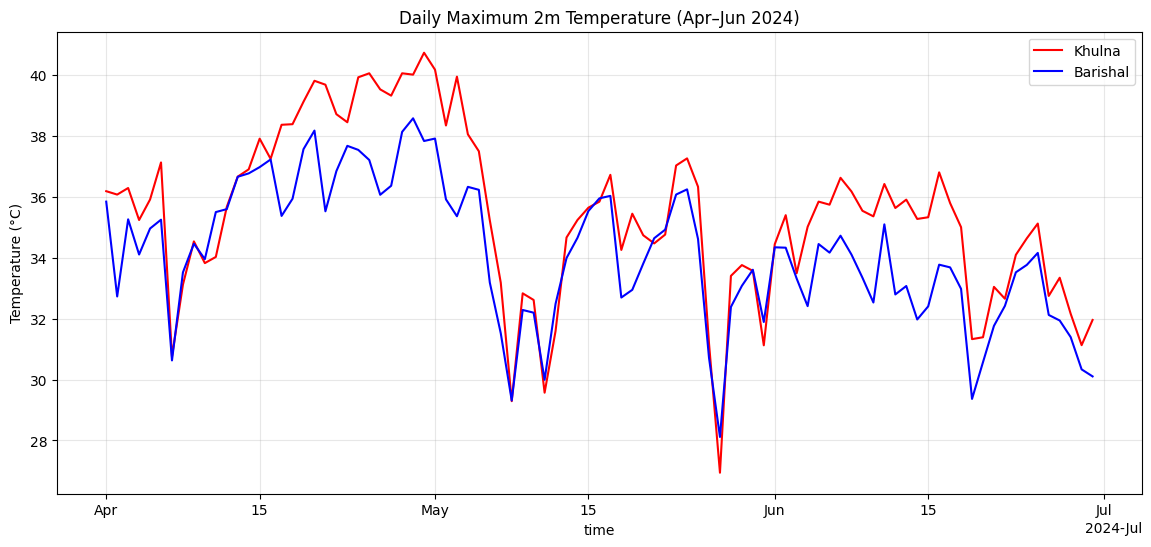

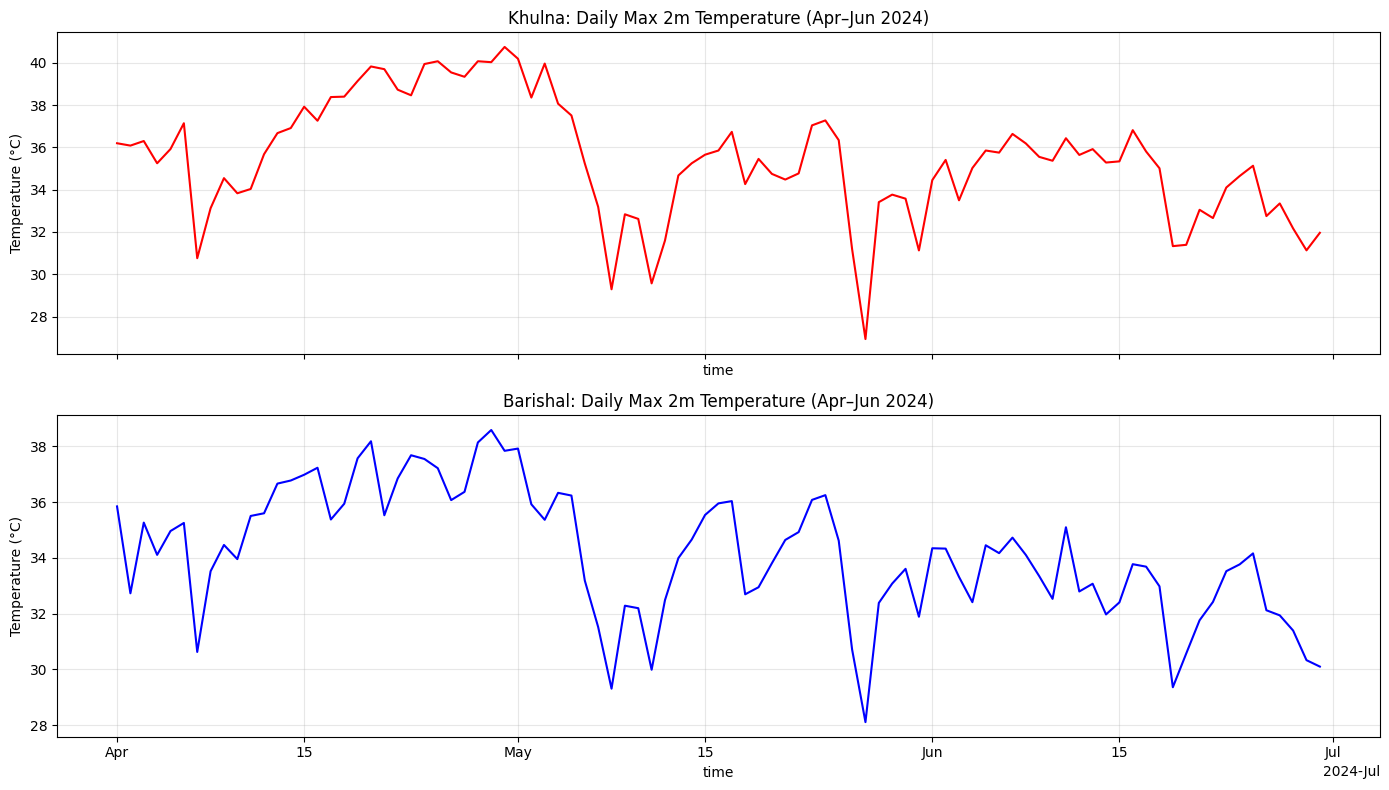

In [34]:

# --- Coordinates for Khulna and Barishal ---
khulna_lat, khulna_lon = 22.8, 89.6
barishal_lat, barishal_lon = 22.7, 90.4

# --- Select nearest grid points ---
khulna = ds['t2m'].sel(latitude=khulna_lat, longitude=khulna_lon, method='nearest')
barishal = ds['t2m'].sel(latitude=barishal_lat, longitude=barishal_lon, method='nearest')

# --- Subset April–June 2024 ---
subset = slice("2024-04-01", "2024-06-30")
khulna_3m = khulna.sel(valid_time=subset) - 273.15  # convert to °C
barishal_3m = barishal.sel(valid_time=subset) - 273.15

# --- Resample to daily maximum ---
khulna_dailymax = khulna_3m.resample(valid_time="1D").max()
barishal_dailymax = barishal_3m.resample(valid_time="1D").max()

# --- Plot combined daily max series ---
plt.figure(figsize=(14,6))
khulna_dailymax.plot(label="Khulna", color="red")
barishal_dailymax.plot(label="Barishal", color="blue")
plt.title("Daily Maximum 2m Temperature (Apr–Jun 2024)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot separate daily max series ---
fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)

khulna_dailymax.plot(ax=axes[0], color="red")
axes[0].set_title("Khulna: Daily Max 2m Temperature (Apr–Jun 2024)")
axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(True, alpha=0.3)

barishal_dailymax.plot(ax=axes[1], color="blue")
axes[1].set_title("Barishal: Daily Max 2m Temperature (Apr–Jun 2024)")
axes[1].set_ylabel("Temperature (°C)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


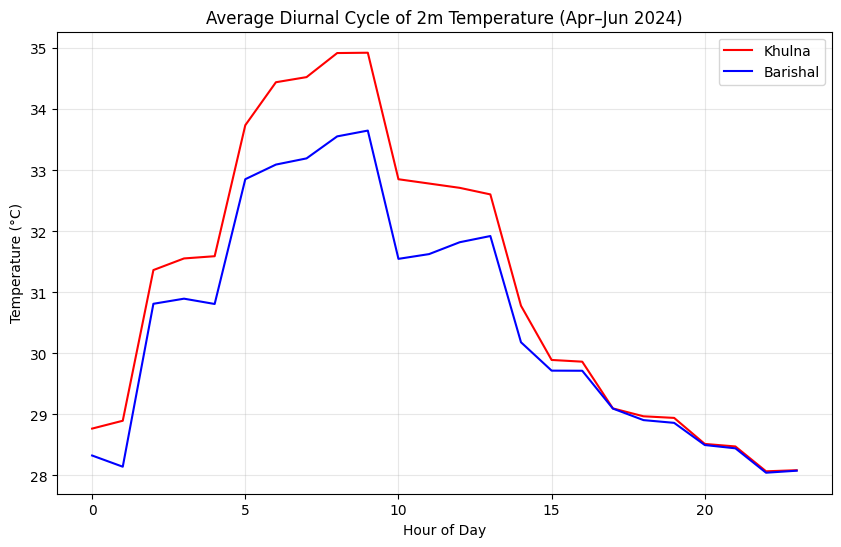

In [35]:

# --- Select nearest grid points ---
khulna = ds['t2m'].sel(latitude=khulna_lat, longitude=khulna_lon, method='nearest')
barishal = ds['t2m'].sel(latitude=barishal_lat, longitude=barishal_lon, method='nearest')

# --- Subset Apr–Jun 2024 ---
subset = slice("2024-04-01", "2024-06-30")
khulna_3m = khulna.sel(valid_time=subset) - 273.15
barishal_3m = barishal.sel(valid_time=subset) - 273.15

# --- Group by hour of day to get mean diurnal cycle ---
khulna_diurnal = khulna_3m.groupby(khulna_3m['valid_time'].dt.hour).mean()
barishal_diurnal = barishal_3m.groupby(barishal_3m['valid_time'].dt.hour).mean()

# --- Plot diurnal cycle ---
plt.figure(figsize=(10,6))
khulna_diurnal.plot(label="Khulna", color="red")
barishal_diurnal.plot(label="Barishal", color="blue")
plt.title("Average Diurnal Cycle of 2m Temperature (Apr–Jun 2024)")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


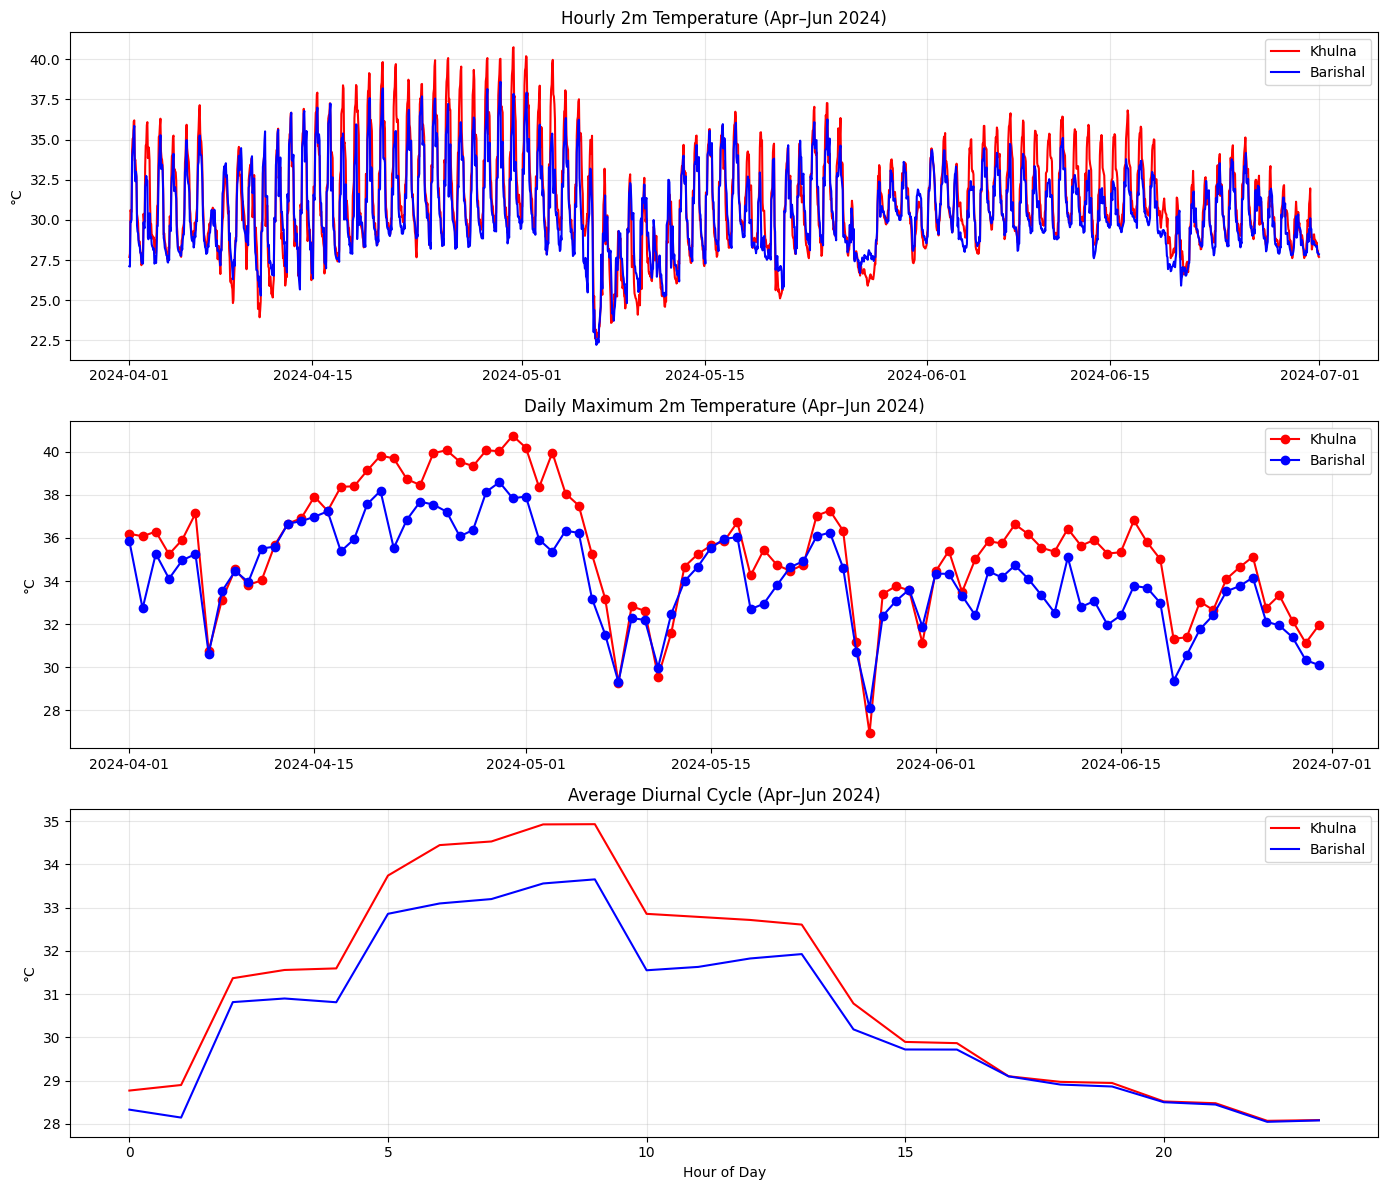

In [63]:
import xarray as xr
import matplotlib.pyplot as plt

# Detect the time coordinate name
time_coord = [c for c in ds.coords if 'time' in c][0]  # picks 'time' or 'valid_time'

# Coordinates for Khulna and Barishal
khulna_lat, khulna_lon = 22.8, 89.6
barishal_lat, barishal_lon = 22.7, 90.4

# Select nearest grid points
khulna = ds['t2m'].sel(latitude=khulna_lat, longitude=khulna_lon, method='nearest')
barishal = ds['t2m'].sel(latitude=barishal_lat, longitude=barishal_lon, method='nearest')

# Subset Apr–Jun 2024
subset = slice("2024-04-01", "2024-06-30")
khulna_3m = khulna.sel({time_coord: subset}) - 273.15
barishal_3m = barishal.sel({time_coord: subset}) - 273.15

# Daily maximums
khulna_dailymax = khulna_3m.resample({time_coord: "1D"}).max()
barishal_dailymax = barishal_3m.resample({time_coord: "1D"}).max()

# Diurnal cycle
khulna_diurnal = khulna_3m.groupby(khulna_3m[time_coord].dt.hour).mean()
barishal_diurnal = barishal_3m.groupby(barishal_3m[time_coord].dt.hour).mean()

# Multi-panel figure
fig, axes = plt.subplots(3, 1, figsize=(14,12))

# Panel 1: Hourly
axes[0].plot(khulna_3m[time_coord], khulna_3m, color="red", label="Khulna")
axes[0].plot(barishal_3m[time_coord], barishal_3m, color="blue", label="Barishal")
axes[0].set_title("Hourly 2m Temperature (Apr–Jun 2024)")
axes[0].set_ylabel("°C")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: Daily max
axes[1].plot(khulna_dailymax[time_coord], khulna_dailymax, "o-", color="red", label="Khulna")
axes[1].plot(barishal_dailymax[time_coord], barishal_dailymax, "o-", color="blue", label="Barishal")
axes[1].set_title("Daily Maximum 2m Temperature (Apr–Jun 2024)")
axes[1].set_ylabel("°C")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: Diurnal cycle
axes[2].plot(khulna_diurnal.indexes['hour'], khulna_diurnal, color="red", label="Khulna")
axes[2].plot(barishal_diurnal.indexes['hour'], barishal_diurnal, color="blue", label="Barishal")
axes[2].set_title("Average Diurnal Cycle (Apr–Jun 2024)")
axes[2].set_xlabel("Hour of Day"); axes[2].set_ylabel("°C")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


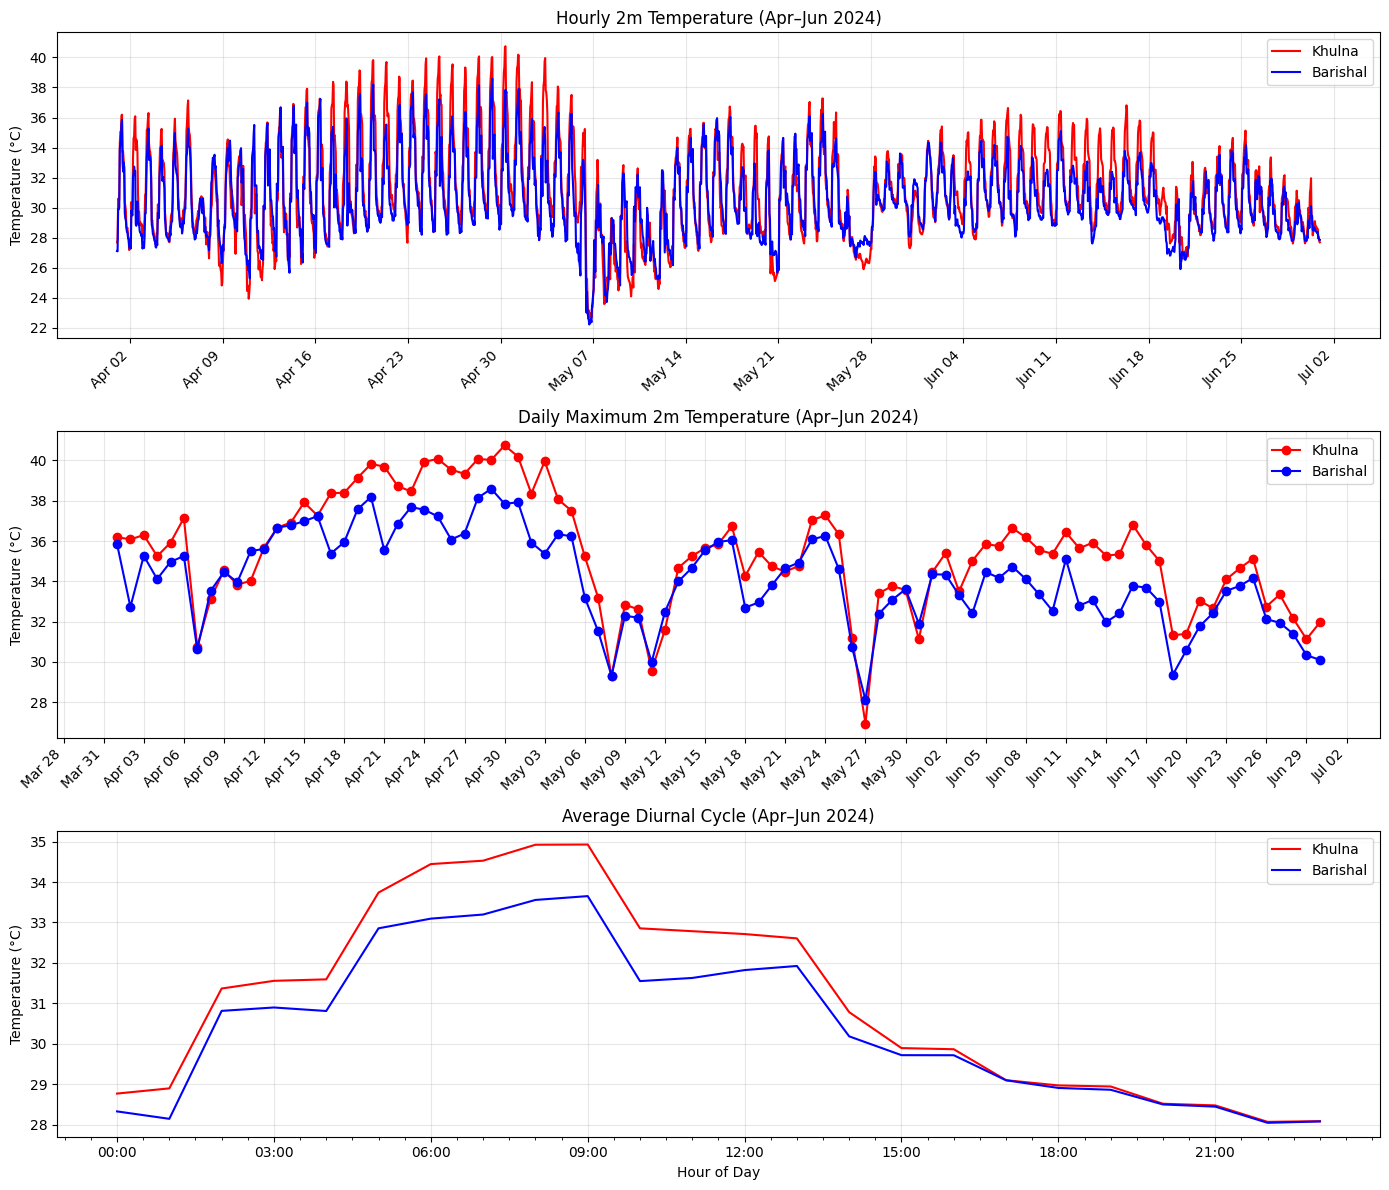

In [68]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Detect the time coordinate name
time_coord = [c for c in ds.coords if 'time' in c][0]  # picks 'time' or 'valid_time'

# Coordinates for Khulna and Barishal
khulna_lat, khulna_lon = 22.8, 89.6
barishal_lat, barishal_lon = 22.7, 90.4

# Select nearest grid points
khulna = ds['t2m'].sel(latitude=khulna_lat, longitude=khulna_lon, method='nearest')
barishal = ds['t2m'].sel(latitude=barishal_lat, longitude=barishal_lon, method='nearest')

# Subset Apr–Jun 2024
subset = slice("2024-04-01", "2024-06-30")
khulna_3m = khulna.sel({time_coord: subset}) - 273.15
barishal_3m = barishal.sel({time_coord: subset}) - 273.15

# Daily maximums
khulna_dailymax = khulna_3m.resample({time_coord: "1D"}).max()
barishal_dailymax = barishal_3m.resample({time_coord: "1D"}).max()

# Diurnal cycle
khulna_diurnal = khulna_3m.groupby(khulna_3m[time_coord].dt.hour).mean()
barishal_diurnal = barishal_3m.groupby(barishal_3m[time_coord].dt.hour).mean()

# Multi-panel figure
fig, axes = plt.subplots(3, 1, figsize=(14,12))

import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Panel 1: Hourly
axes[0].plot(khulna_3m[time_coord], khulna_3m, color="red", label="Khulna")
axes[0].plot(barishal_3m[time_coord], barishal_3m, color="blue", label="Barishal")
axes[0].set_title("Hourly 2m Temperature (Apr–Jun 2024)")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# X-axis: প্রতি সপ্তাহে টিক, মাস-দিন ফরম্যাট
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=7))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

# Y-axis: প্রতি 2°C এ টিক
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(2))

# Panel 2: Daily max
axes[1].plot(khulna_dailymax[time_coord], khulna_dailymax, "o-", color="red", label="Khulna")
axes[1].plot(barishal_dailymax[time_coord], barishal_dailymax, "o-", color="blue", label="Barishal")
axes[1].set_title("Daily Maximum 2m Temperature (Apr–Jun 2024)")
axes[1].set_ylabel("Temperature (°C)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# X-axis formatting: প্রতি 3 দিনে টিক, মাস-দিন ফরম্যাট
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

# Y-axis formatting: প্রতি 2°C এ টিক
axes[1].yaxis.set_major_locator(ticker.MultipleLocator(2))

# Panel 3: Diurnal cycle
axes[2].plot(khulna_diurnal['hour'], khulna_diurnal, color="red", label="Khulna")
axes[2].plot(barishal_diurnal['hour'], barishal_diurnal, color="blue", label="Barishal")
axes[2].set_title("Average Diurnal Cycle (Apr–Jun 2024)")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Temperature (°C)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# X-axis formatting: প্রতি 1 ঘন্টায় টিক, কিন্তু লেবেলগুলো স্পষ্টভাবে দেখানো
axes[2].xaxis.set_major_locator(ticker.MultipleLocator(1))   # প্রতি ঘন্টায় টিক
axes[2].xaxis.set_minor_locator(ticker.MultipleLocator(0.5)) # হালকা সাব-টিক
axes[2].set_xticks(range(0,24,3))                            # প্রতি 3 ঘন্টায় লেবেল (0,3,6,...,21)
axes[2].set_xticklabels([f"{h:02d}:00" for h in range(0,24,3)])

plt.tight_layout()
plt.show()


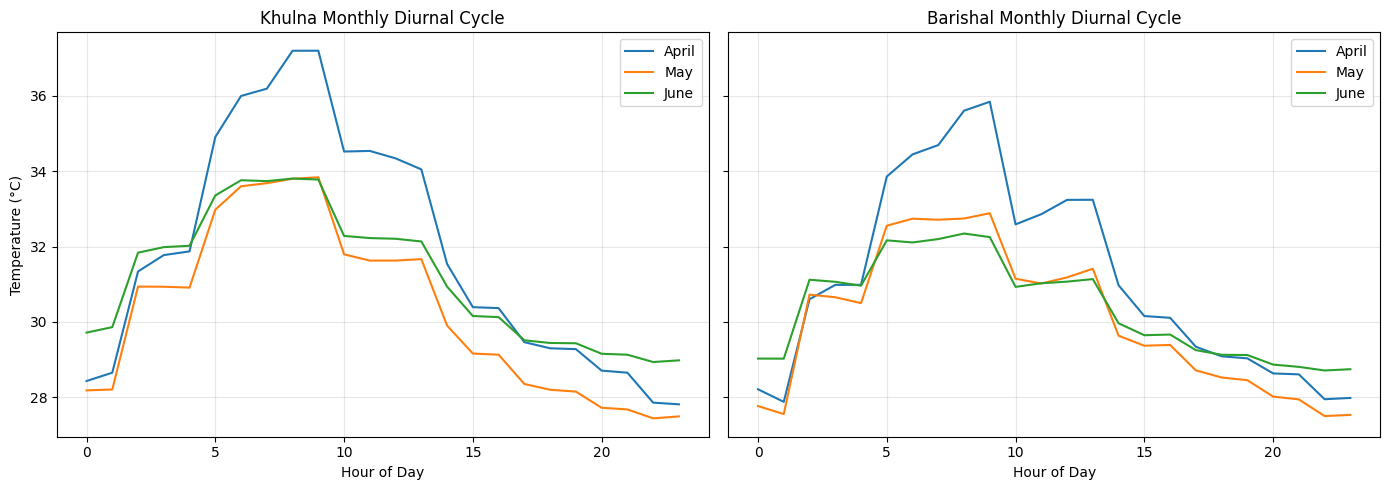

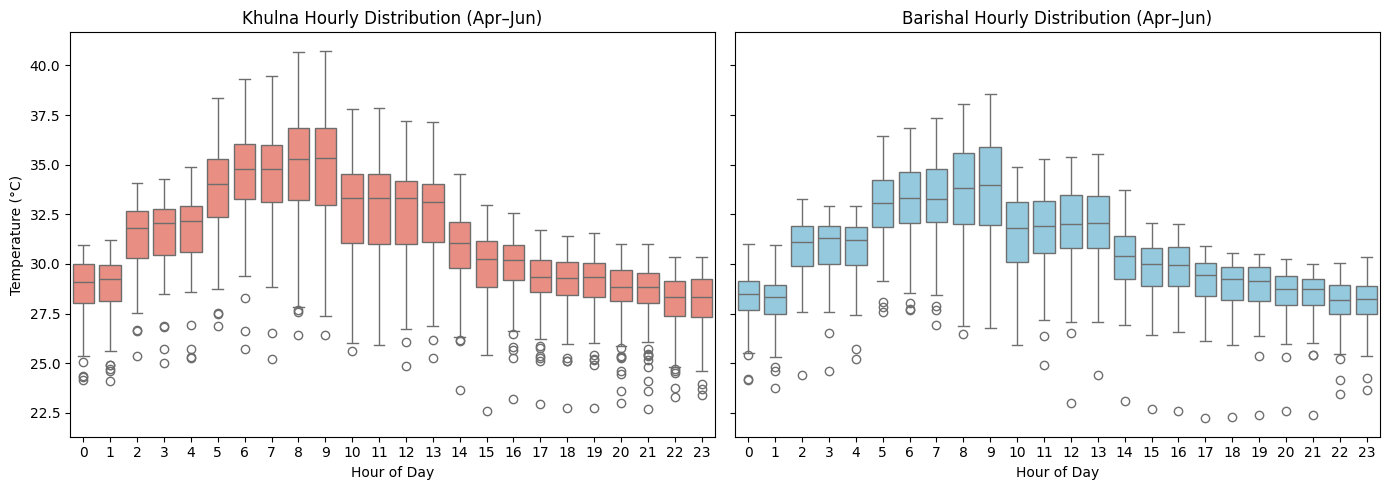

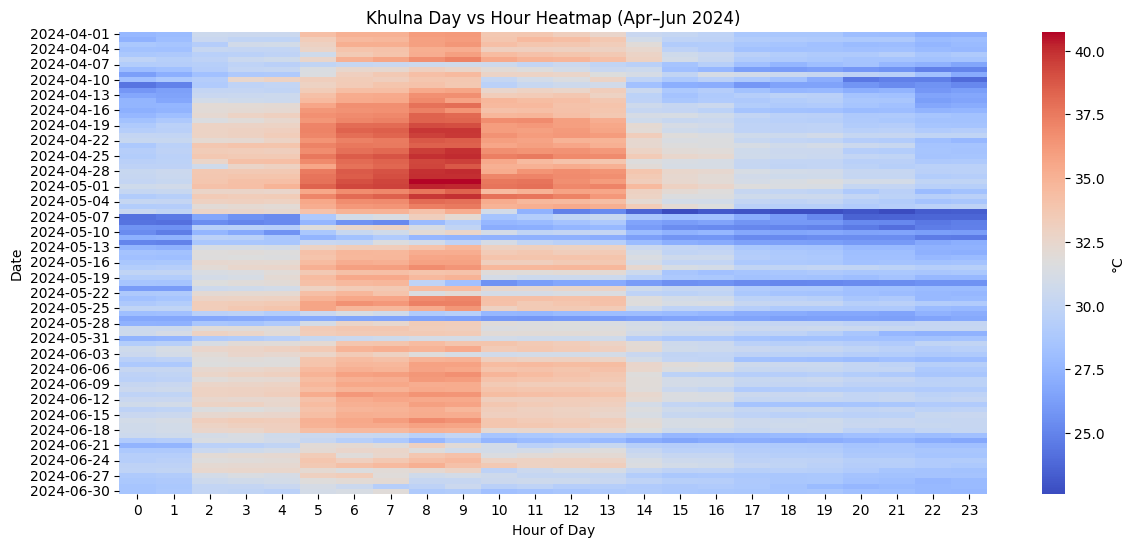

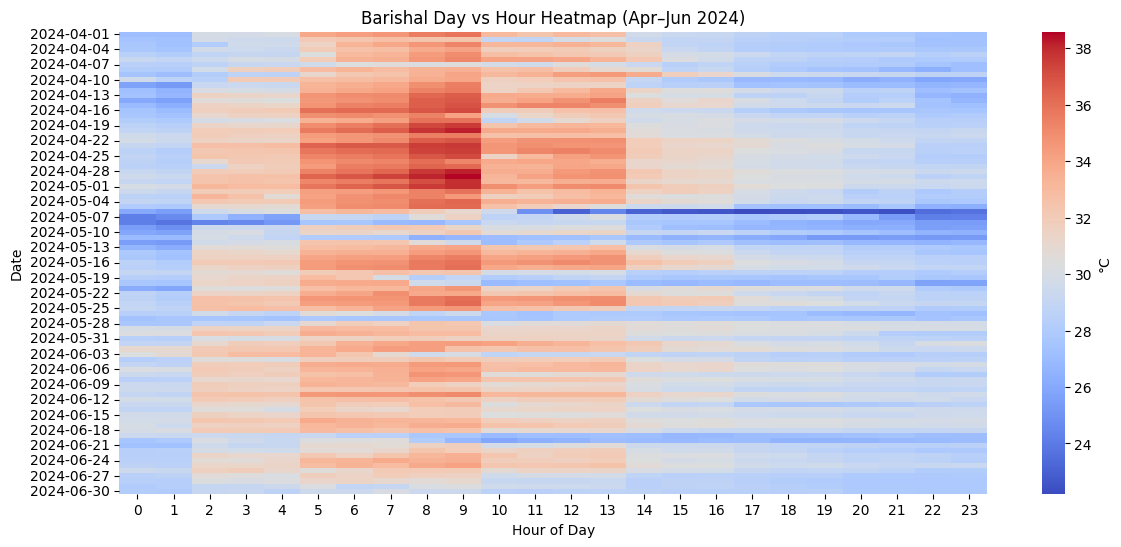

In [70]:
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ধরে নিচ্ছি ds, time_coord, khulna_3m, barishal_3m আগেই তৈরি আছে

# Convert to pandas DataFrame
df_khulna = khulna_3m.to_dataframe().reset_index()
df_barishal = barishal_3m.to_dataframe().reset_index()

# Force numeric conversion
df_khulna['t2m'] = pd.to_numeric(df_khulna['t2m'], errors='coerce')
df_barishal['t2m'] = pd.to_numeric(df_barishal['t2m'], errors='coerce')

# Add month, hour, day columns
df_khulna['month'] = df_khulna[time_coord].dt.month
df_khulna['hour'] = df_khulna[time_coord].dt.hour
df_khulna['day'] = df_khulna[time_coord].dt.date

df_barishal['month'] = df_barishal[time_coord].dt.month
df_barishal['hour'] = df_barishal[time_coord].dt.hour
df_barishal['day'] = df_barishal[time_coord].dt.date

# --- 1. Monthly diurnal cycle ---
fig, ax = plt.subplots(1,2, figsize=(14,5), sharey=True)

for m, label in zip([4,5,6], ['April','May','June']):
    avg = df_khulna[df_khulna['month']==m].groupby('hour')['t2m'].mean()
    ax[0].plot(avg.index, avg.values, label=label)
ax[0].set_title("Khulna Monthly Diurnal Cycle")
ax[0].set_xlabel("Hour of Day"); ax[0].set_ylabel("Temperature (°C)")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

for m, label in zip([4,5,6], ['April','May','June']):
    avg = df_barishal[df_barishal['month']==m].groupby('hour')['t2m'].mean()
    ax[1].plot(avg.index, avg.values, label=label)
ax[1].set_title("Barishal Monthly Diurnal Cycle")
ax[1].set_xlabel("Hour of Day")
ax[1].legend(); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. Boxplot by hour ---
fig, ax = plt.subplots(1,2, figsize=(14,5), sharey=True)
sns.boxplot(x="hour", y="t2m", data=df_khulna, ax=ax[0], color="salmon")
ax[0].set_title("Khulna Hourly Distribution (Apr–Jun)")
ax[0].set_xlabel("Hour of Day"); ax[0].set_ylabel("Temperature (°C)")

sns.boxplot(x="hour", y="t2m", data=df_barishal, ax=ax[1], color="skyblue")
ax[1].set_title("Barishal Hourly Distribution (Apr–Jun)")
ax[1].set_xlabel("Hour of Day")

plt.tight_layout()
plt.show()

# --- 3. Heatmap (Day vs Hour) ---
pivot_khulna = df_khulna.pivot_table(index='day', columns='hour', values='t2m')
plt.figure(figsize=(14,6))
sns.heatmap(pivot_khulna, cmap="coolwarm", cbar_kws={'label':'°C'})
plt.title("Khulna Day vs Hour Heatmap (Apr–Jun 2024)")
plt.xlabel("Hour of Day"); plt.ylabel("Date")
plt.show()

pivot_barishal = df_barishal.pivot_table(index='day', columns='hour', values='t2m')
plt.figure(figsize=(14,6))
sns.heatmap(pivot_barishal, cmap="coolwarm", cbar_kws={'label':'°C'})
plt.title("Barishal Day vs Hour Heatmap (Apr–Jun 2024)")
plt.xlabel("Hour of Day"); plt.ylabel("Date")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import xarray as xr

ds = xr.open_dataset('/content/drive/MyDrive/data_stream-oper_stepType-instant.nc')
print(ds)